In [4]:
import sys
sys.path.append('../code')

import os

import jax
import jax.numpy as jnp
import jaxley as jx

import matplotlib.pyplot as plt
import numpy as np
from network_utils import (make_network, set_train_parameters, simulate, gaussian_tuning,
                           StimSynapse, get_currents, IonotropicSynapse, get_prior_dict)
from jax import config
import pickle
from networkx import connected_watts_strogatz_graph, adjacency_matrix,gaussian_random_partition_graph
# from jaxley_mech.synapses.destexhe98 import AMPA, GABAa, GABAb, NMDA

import pandas as pd
import seaborn as sns

from neurodsp.spectral import compute_spectrum
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA

from tqdm import tqdm

config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")
# config.update("jax_platform_name", "gpu")

In [30]:
data_path =  '/users/ntolley/data/ntolley/dendractor/intrinsic_permutations/random_initialization'
# data_path =  '/users/ntolley/data/ntolley/dendractor/intrinsic_permutations/random_stimulation'

file_list = os.listdir(data_path)

random_init_dict = dict()
for file_idx in tqdm(range(len(file_list))):
    with open(f'{data_path}/{file_list[file_idx]}', 'rb') as f:
        res_dict = pickle.load(f)
    
    random_init_dict[res_dict['name']] = res_dict

100%|██████████| 9/9 [00:18<00:00,  2.06s/it]


In [31]:
print(list(random_init_dict.keys()))

['Edend_Idend', 'Edend_Isoma', 'Edend_Isomadend', 'Esoma_Idend', 'Esoma_Isoma', 'Esoma_Isomadend', 'Esomadend_Idend', 'Esomadend_Isoma', 'Esomadend_Isomadend']


In [70]:
# res_dict = random_init_dict['Esomadend_Isomadend']
res_dict = random_init_dict['Esomadend_Idend']
# res_dict = random_init_dict['Esoma_Isomadend']
# res_dict = random_init_dict['Esomadend_Isoma']
# res_dict = random_init_dict['Esoma_Isoma']
# res_dict = random_init_dict['Edend_Idend']



name = res_dict['name']
output_array = res_dict['output_array']
targets = res_dict['targets']
gid_ranges = res_dict['gid_ranges']
input_list = res_dict['input_list']
num_cond = input_list.shape[0]
print(name)

Esomadend_Idend


In [71]:
t_max = 2000
dt = 0.25 # simulation output downsampled by factor of 10
fs = (1/dt) * 1e3
time_vec = np.arange(0, t_max, dt)
downsample_factor = 10
burn_in = int(8000 / downsample_factor)

In [83]:
rate_gids = list(gid_ranges['E_rate'])
rates = output_array[:, rate_gids, :]

x_train = list()
for sim_idx in range(0, output_array.shape[0], num_cond):
    temp_list = list()
    for cond_idx in range(num_cond):
        temp_list.append(output_array[sim_idx + cond_idx, gid_ranges['E_rate'], :])
    x_train.append(np.concatenate(temp_list, axis=1).T)


num_model_sims = 1

error_list = list()
model = Ridge(alpha=2.0)
rate_fit = np.concatenate([x[burn_in:, :] for x in x_train[:num_model_sims]])
target_fit = np.concatenate([targets[burn_in:, :] for _ in range(num_model_sims)])
model.fit(rate_fit, target_fit)

# for sim_idx in range(num_model_sims, len(x_train)):
for sim_idx in range(len(x_train)):
    rate_pred = x_train[sim_idx]
    y_pred = model.predict(rate_pred[burn_in:, :])


    error = np.mean(np.square(targets[burn_in:, :] - y_pred))
    error_list.append(error)

print(error_list)

[0.1558006031607966, 0.3564180021376857, 0.41906379251864556, 0.27674600258685916, 0.43711826640349205, 0.2991263473197274, 0.3577792895214337, 0.3645529204083939, 0.3694834446090558, 0.3285851769987665, 0.3517815599673566, 0.30454612190065317, 0.31271527130329996, 0.3191198083346356, 0.30477884120265614, 0.3736092057817638, 0.41384034813152154, 0.29525242864291706, 0.2849529916767174, 0.3575833504221573]


In [90]:
y_pred_list = list()
target_list = list()

sim_start_idx = 18 * num_cond
for cond_idx in range(num_cond):
    rate_plot_data = output_array[sim_start_idx + cond_idx, gid_ranges['E_rate'], :].T
    y_pred = model.predict(rate_plot_data)

    y_pred_list.append(y_pred)
    target_list.append(res_dict['targets_concat'][cond_idx, :, :].T)

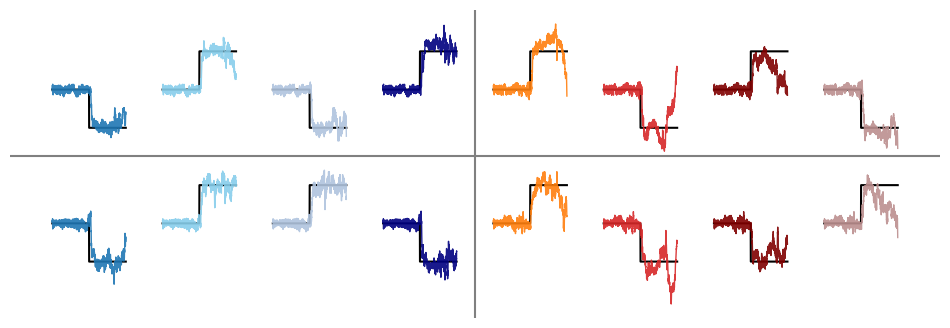

In [91]:
color_list = ['C0', 'skyblue', 'lightsteelblue', 'navy', 'C1', 'C3', 'maroon', 'rosybrown']
time_offset = 3000
y_offset = -7
plt.figure(figsize=(12,4))
for cond_idx in range(num_cond):
    x_offset = time_offset * cond_idx


    plt.plot(time_vec + x_offset, target_list[cond_idx][:-1, 0], color='k')
    plt.plot(time_vec + x_offset, y_pred_list[cond_idx][:-1, 0], color=color_list[cond_idx], alpha=0.9, linewidth=1)

    plt.plot(time_vec + x_offset, target_list[cond_idx][:-1, 1] + y_offset, color='k')
    plt.plot(time_vec + x_offset, y_pred_list[cond_idx][:-1, 1] + y_offset, color=color_list[cond_idx], alpha=0.9, linewidth=1)


    plt.axis('off')
plt.axhline(y_offset/2, color='grey', linestyle='-')
plt.axvline((time_offset * 4) - 500, color='grey', linestyle='-')
# plt.savefig('full_trajectory_set.svg')

In [75]:
input_names = [
    'Pro (-1,-1)', 'Pro (1,1)', 'Pro (-1,1)', 'Pro (1,-1)',
    'Anti (-1,-1)', 'Anti (1,1)', 'Anti (-1,1)', 'Anti (1,-1)']

In [76]:
gid_ranges

{'E': range(0, 100),
 'I': range(100, 150),
 'context': range(150, 200),
 'cue': range(200, 250),
 'E_rate': range(250, 350),
 'I_rate': range(350, 400)}

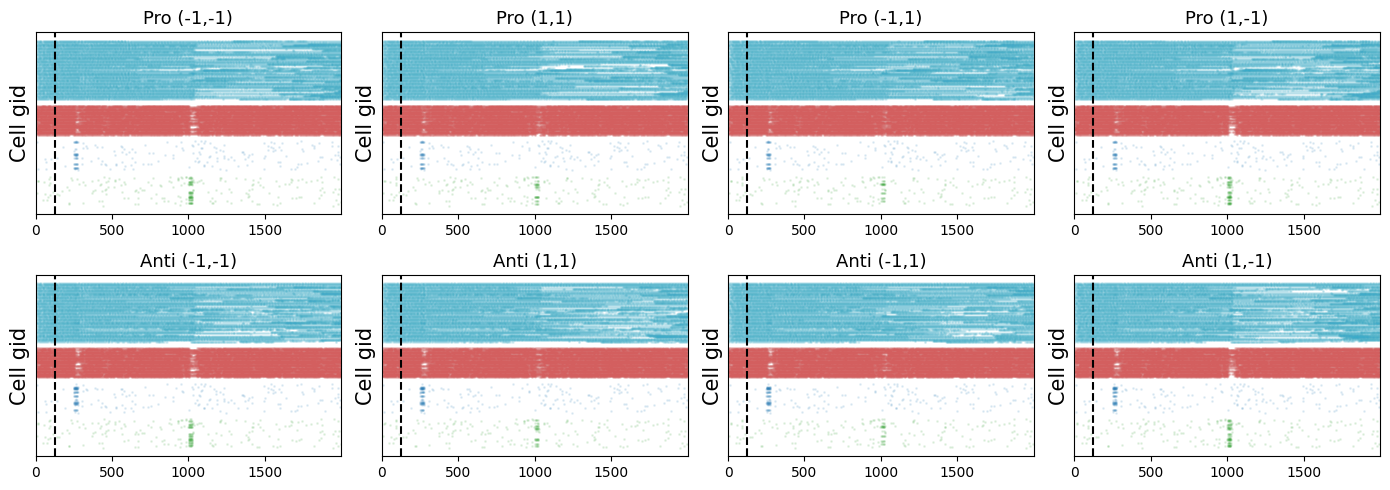

In [77]:
fontsize = 15
ticksize = 10
labelsize=13
threshold = 0.0

spike_color_dict = {'E': '#37abc8', 'I': '#d35f5f', 'context': '#1f77b4', 'cue': '#2ca02c'}
plt.figure(figsize=(14,5))
for plot_idx, sim_idx in enumerate(range(num_cond)):
    # sim_idx *= num_cond
    # sim_idx += 10
    
    plt.subplot(2,4, plot_idx+1)
    s = output_array[sim_idx, :]
    above_threshold = s > threshold
    spike_gids, spike_times = np.where(np.diff(above_threshold.astype(int), axis=1) == 1)

    for type_idx, (name, cell_range) in enumerate(gid_ranges.items()):
        if name not in ['output', 'E_rate', 'I_rate']:
            mask = np.isin(spike_gids, cell_range)
            plt.scatter(spike_times[mask] * dt, -spike_gids[mask] - type_idx * 10, label=name, s=1, alpha=0.1, color=spike_color_dict[name])
    plt.ylabel('Cell gid', fontsize=fontsize)
    plt.yticks([])
    plt.xlim(0, time_vec[-1])
    plt.axvline(500 * dt, color='k', linestyle='--')
    plt.title(input_names[plot_idx], fontsize=labelsize)
    plt.tight_layout()

In [78]:
pca = PCA()
pca.fit(np.concatenate(x_train))

PCA()

In [79]:
def make_trajectory_figure(points1, points2, points3, points4, start_idx, end_idx, ax, dim1=0, dim2=1, dim3=2,
                           color1='C0', color2='C9', color3='C1', color4='C3',
                           label1=None, label2=None, label3=None, label4=None):
    ax.grid(False)
    # ax.set_xlabel(f'PC{dim1+1}', fontsize=labelsize)
    # ax.set_ylabel(f'PC{dim2+1}', fontsize=labelsize)
    # ax.set_zlabel(f'PC{dim3+1}', fontsize=labelsize)

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_zlabel('')

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])


    ax.plot(points1[start_idx:end_idx,dim1], points1[start_idx:end_idx, dim2], points1[start_idx:end_idx, dim3], color=color1, label=label1)
    ax.plot(points2[start_idx:end_idx,dim1], points2[start_idx:end_idx, dim2], points2[start_idx:end_idx, dim3], color=color2, label=label2)
    ax.plot(points3[start_idx:end_idx,dim1], points3[start_idx:end_idx, dim2], points3[start_idx:end_idx, dim3], color=color3, label=label3)
    ax.plot(points4[start_idx:end_idx,dim1], points4[start_idx:end_idx, dim2], points4[start_idx:end_idx, dim3], color=color4, label=label4)


    ax.scatter(points1[start_idx,dim1], points1[start_idx, dim2], points1[start_idx, dim3], color='k', marker='*', s=50)
    ax.scatter(points2[start_idx,dim1], points2[start_idx, dim2], points2[start_idx, dim3], color='k', marker='*', s=50)

    ax.scatter(points1[cue_idx,dim1], points1[cue_idx, dim2], points1[cue_idx, dim3], color='k')
    ax.scatter(points2[cue_idx,dim1], points2[cue_idx, dim2], points2[cue_idx, dim3], color='k')

    ax.scatter(points1[end_idx,dim1], points1[end_idx, dim2], points1[end_idx, dim3], color=color1, s=100, edgecolor='k')
    ax.scatter(points2[end_idx,dim1], points2[end_idx, dim2], points2[end_idx, dim3], color=color2, s=100, edgecolor='k')
    ax.scatter(points3[end_idx,dim1], points3[end_idx, dim2], points3[end_idx, dim3], color=color3, s=100, edgecolor='k')
    ax.scatter(points4[end_idx,dim1], points4[end_idx, dim2], points4[end_idx, dim3], color=color4, s=100, edgecolor='k')


    ax.view_init(elev=30., azim=-200, roll=0)

    # plt.tight_layout()
    # plt.show()

In [80]:
ticksize = 11
labelsize = 15

sim_idx1, sim_idx2, sim_idx3, sim_idx4 = 0, 1, 2, 3
sim_idx5, sim_idx6, sim_idx7, sim_idx8 = 4, 5, 6, 7


# sim_idx1, sim_idx2 = 0,4
# sim_idx3, sim_idx4 = 1,5

# sim_idx1, sim_idx2 = 2,6
# sim_idx3, sim_idx4 = 3,7

cue_idx = 4000

points1 = pca.transform(output_array[sim_idx1, gid_ranges['E_rate'], :].T)
points2 = pca.transform(output_array[sim_idx2, gid_ranges['E_rate'], :].T)
points3 = pca.transform(output_array[sim_idx3, gid_ranges['E_rate'], :].T)
points4 = pca.transform(output_array[sim_idx4, gid_ranges['E_rate'], :].T)

points5 = pca.transform(output_array[sim_idx5, gid_ranges['E_rate'], :].T)
points6 = pca.transform(output_array[sim_idx6, gid_ranges['E_rate'], :].T)
points7 = pca.transform(output_array[sim_idx7, gid_ranges['E_rate'], :].T)
points8 = pca.transform(output_array[sim_idx8, gid_ranges['E_rate'], :].T)



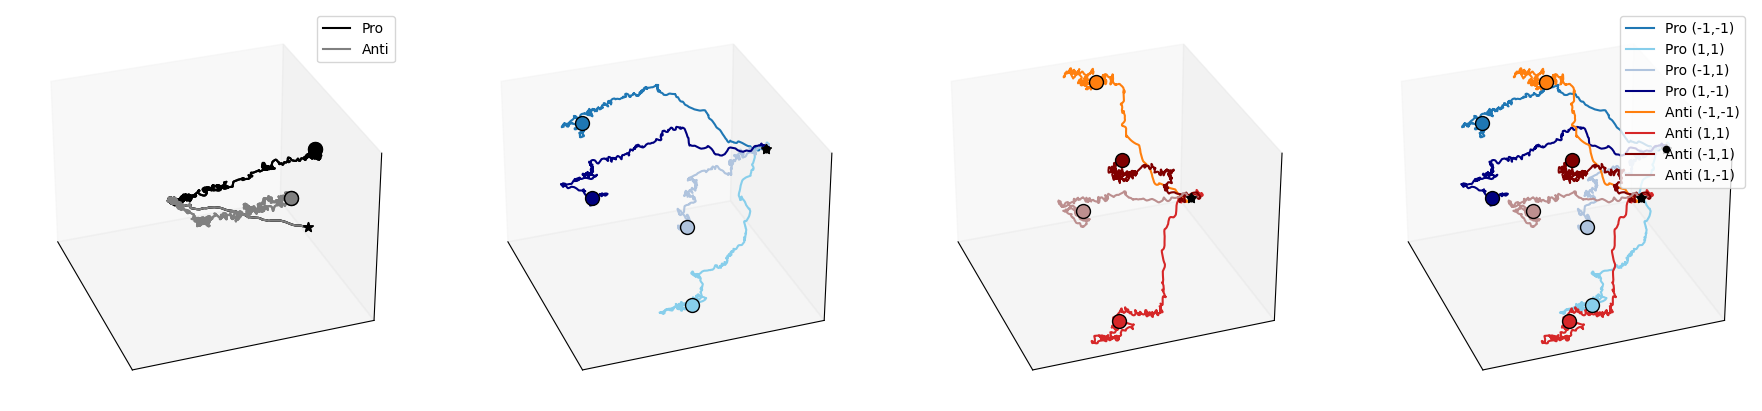

In [81]:
dim1, dim2, dim3 = 2,3,4

fig = plt.figure(figsize=(18,4), constrained_layout=True)
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')


make_trajectory_figure(points1, points5, points1, points5, 0, cue_idx, ax1, dim1, dim2, dim3,
                       color1='k', color2='grey', color3='k', color4='grey', label1='Pro', label2='Anti')

make_trajectory_figure(points1, points2, points3, points4, cue_idx, cue_idx+2000, ax2, dim1, dim2, dim3,
                       color1='C0', color2='skyblue', color3='lightsteelblue', color4='navy',
                       label1=input_names[sim_idx1], label2=input_names[sim_idx2], label3=input_names[sim_idx3], label4=input_names[sim_idx4])

make_trajectory_figure(points5, points6, points7, points8, cue_idx, cue_idx+2000, ax3, dim1, dim2, dim3,
                       color1='C1', color2='C3', color3='maroon', color4='rosybrown',
                       label1=input_names[sim_idx5], label2=input_names[sim_idx6], label3=input_names[sim_idx7], label4=input_names[sim_idx8])


make_trajectory_figure(points1, points2, points3, points4, cue_idx, cue_idx+2000, ax4, dim1, dim2, dim3,
                       color1='C0', color2='skyblue', color3='lightsteelblue', color4='navy',
                       label1=input_names[sim_idx1], label2=input_names[sim_idx2], label3=input_names[sim_idx3], label4=input_names[sim_idx4])

make_trajectory_figure(points5, points6, points7, points8, cue_idx, cue_idx+2000, ax4, dim1, dim2, dim3,
                       color1='C1', color2='C3', color3='maroon', color4='rosybrown',
                       label1=input_names[sim_idx5], label2=input_names[sim_idx6], label3=input_names[sim_idx7], label4=input_names[sim_idx8])

limits = [(-3, 5), (-4, 4), (-3, 2)]
# limits = [(-9, 5), (-5, 6), (-5, 3.4)]
for ax_plot in [ax1, ax2, ax3, ax4]:
    ax_plot.set_xlim(limits[0])
    ax_plot.set_ylim(limits[1])
    ax_plot.set_zlim(limits[2])

ax1.legend(loc='upper right')
# ax2.legend(loc='upper right')
# ax3.legend(loc='upper right')
ax4.legend(loc='upper right')
# plt.savefig('cuesoma_context_soma_trajectory2.svg')


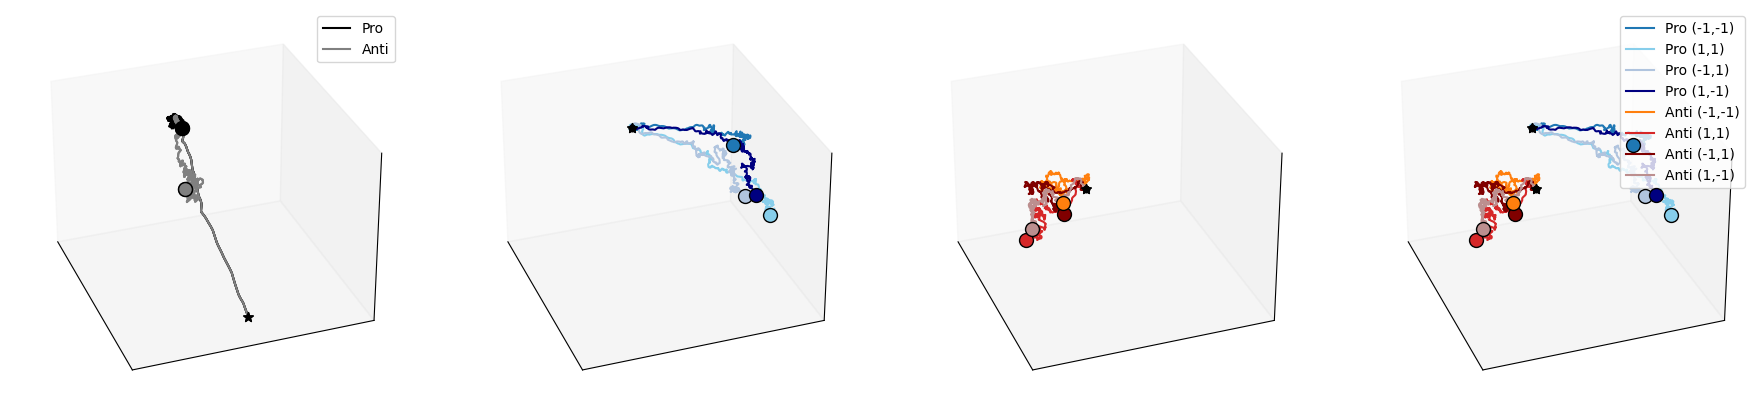

In [82]:
dim1, dim2, dim3 = 0,1,2

fig = plt.figure(figsize=(18,4), constrained_layout=True)
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')


make_trajectory_figure(points1, points5, points1, points5, 0, cue_idx, ax1, dim1, dim2, dim3,
                       color1='k', color2='grey', color3='k', color4='grey', label1='Pro', label2='Anti')

make_trajectory_figure(points1, points2, points3, points4, cue_idx, cue_idx+2000, ax2, dim1, dim2, dim3,
                       color1='C0', color2='skyblue', color3='lightsteelblue', color4='navy',
                       label1=input_names[sim_idx1], label2=input_names[sim_idx2], label3=input_names[sim_idx3], label4=input_names[sim_idx4])

make_trajectory_figure(points5, points6, points7, points8, cue_idx, cue_idx+2000, ax3, dim1, dim2, dim3,
                       color1='C1', color2='C3', color3='maroon', color4='rosybrown',
                       label1=input_names[sim_idx5], label2=input_names[sim_idx6], label3=input_names[sim_idx7], label4=input_names[sim_idx8])


make_trajectory_figure(points1, points2, points3, points4, cue_idx, cue_idx+2000, ax4, dim1, dim2, dim3,
                       color1='C0', color2='skyblue', color3='lightsteelblue', color4='navy',
                       label1=input_names[sim_idx1], label2=input_names[sim_idx2], label3=input_names[sim_idx3], label4=input_names[sim_idx4])

make_trajectory_figure(points5, points6, points7, points8, cue_idx, cue_idx+2000, ax4, dim1, dim2, dim3,
                       color1='C1', color2='C3', color3='maroon', color4='rosybrown',
                       label1=input_names[sim_idx5], label2=input_names[sim_idx6], label3=input_names[sim_idx7], label4=input_names[sim_idx8])

# limits = [(-3, 5), (-4, 4), (-3, 2)]
limits = [(-9, 5), (-5, 5), (-5, 3.4)]
for ax_plot in [ax1, ax2, ax3, ax4]:
    ax_plot.set_xlim(limits[0])
    ax_plot.set_ylim(limits[1])
    ax_plot.set_zlim(limits[2])

ax1.legend(loc='upper right')
# ax2.legend(loc='upper right')
# ax3.legend(loc='upper right')
ax4.legend(loc='upper right')
# plt.savefig('cuesoma_context_soma_trajectory1.svg')
